<img src="https://upload.wikimedia.org/wikipedia/en/thumb/f/f2/Premier_League_Logo.svg/960px-Premier_League_Logo.svg.png"/>

In [2]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# =========================================
# 2. LOAD DATA
# =========================================

matches = pd.read_csv('Data/Fifa/england-premier-league-matches-2018-to-2019-stats.csv')
teams = pd.read_csv('Data/Fifa/england-premier-league-teams-2018-to-2019-stats.csv')

print("Data loaded successfully.")
print("Matches shape:", matches.shape)
print("Teams shape:", teams.shape)

Data loaded successfully.
Matches shape: (380, 66)
Teams shape: (20, 293)


In [4]:
# =========================================
# 3. FEATURE ENGINEERING
# =========================================
teams['shots_on_target_avg'] = teams['shots_on_target'] / teams['matches_played']
teams['corners_avg'] = teams['corners_total'] / teams['matches_played']
teams['cards_avg'] = teams['cards_total'] / teams['matches_played']

teams = teams.fillna(0)


Performing feature engineering...


In [5]:
# =========================================
# 4. CREATE TARGET VARIABLE
# =========================================

print("\nCreating target variable...")

def get_result(row):
    if row['home_team_goal_count'] > row['away_team_goal_count']:
        return 1  # Home Win
    elif row['home_team_goal_count'] < row['away_team_goal_count']:
        return 2  # Away Win
    else:
        return 0  # Draw

matches['result'] = matches.apply(get_result, axis=1)

print(matches['result'].value_counts())


Creating target variable...
result
1    181
2    128
0     71
Name: count, dtype: int64


In [6]:
# =========================================
# 5. MERGE DATASETS
# =========================================

print("\nMerging datasets...")

team_features = teams[['common_name',
                       'points_per_game',
                       'average_possession',
                       'shots_on_target_avg',
                       'corners_avg',
                       'cards_avg']]

df = matches.merge(team_features,
                   left_on='home_team_name',
                   right_on='common_name')

df = df.merge(team_features,
              left_on='away_team_name',
              right_on='common_name',
              suffixes=('_home', '_away'))

print("Merged dataset shape:", df.shape)


Merging datasets...
Merged dataset shape: (380, 79)


In [7]:
# =========================================
# 6. FEATURE SELECTION
# =========================================

features = [
    'points_per_game_home', 'points_per_game_away',
    'average_possession_home', 'average_possession_away',
    'shots_on_target_avg_home', 'shots_on_target_avg_away',
    'corners_avg_home', 'corners_avg_away',
    'cards_avg_home', 'cards_avg_away'
]

X = df[features]
y = df['result']


In [8]:
# =========================================
# 7. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# =========================================
# 8. MODEL TRAINING
# =========================================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)


Training model...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [10]:
# =========================================
# 9. MODEL EVALUATION
# =========================================

print("\nEvaluating model...")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n===== PERFORMANCE =====")
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Evaluating model...

===== PERFORMANCE =====
Accuracy: 0.5658

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.09      0.10        11
           1       0.61      0.66      0.63        38
           2       0.65      0.63      0.64        27

    accuracy                           0.57        76
   macro avg       0.46      0.46      0.46        76
weighted avg       0.55      0.57      0.56        76




Plotting confusion matrix...


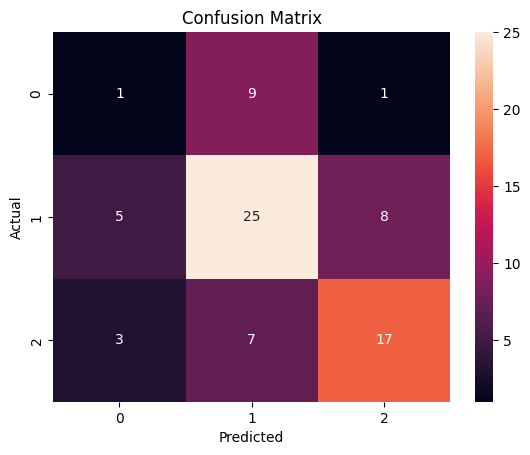

In [11]:
# =========================================
# 10. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Plotting feature importance...


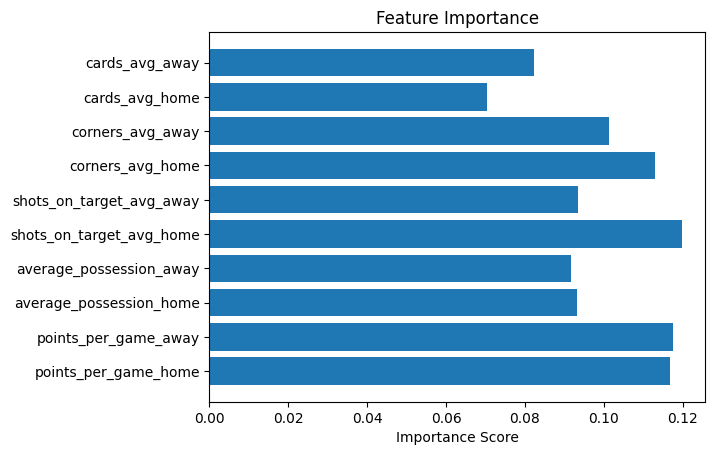

In [12]:
# =========================================
# 11. FEATURE IMPORTANCE
# =========================================
importance = model.feature_importances_
plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()


Plotting result distribution...


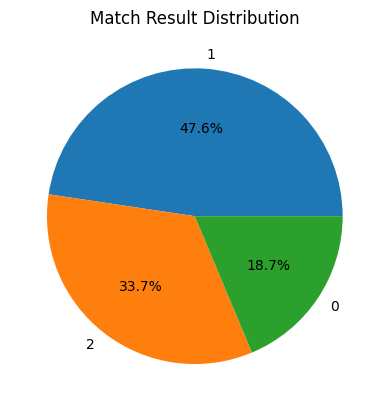

In [13]:
# =========================================
# 12. RESULT DISTRIBUTION
# =========================================

print("\nPlotting result distribution...")

df['result'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Match Result Distribution")
plt.ylabel("")
plt.show()

In [14]:
# =========================================
# 13. SAVE MODEL
# =========================================

joblib.dump(model, "premier_league_model.joblib")

print("\nModel saved as 'premier_league_model.joblib'")



Model saved as 'premier_league_model.joblib'


In [15]:
# =========================================
# 14. SIMPLE PREDICTION FUNCTION
# =========================================

def predict_match(input_data):
    """
    input_data = [ppg_home, ppg_away,
                  possession_home, possession_away,
                  shots_home, shots_away,
                  corners_home, corners_away,
                  cards_home, cards_away]
    """

    prediction = model.predict([input_data])[0]
    if prediction == 1:
        return "Home Win"
    elif prediction == 2:
        return "Away Win"
    else:
        return "Draw"
    

In [18]:
def predict_match(input_data):

    columns = [
        'points_per_game_home', 'points_per_game_away',
        'average_possession_home', 'average_possession_away',
        'shots_on_target_avg_home', 'shots_on_target_avg_away',
        'corners_avg_home', 'corners_avg_away',
        'cards_avg_home', 'cards_avg_away'
    ]

    input_df = pd.DataFrame([input_data], columns=columns)

    prediction = model.predict(input_df)[0]

    if prediction == 1:
        return "Home Win"
    elif prediction == 2:
        return "Away Win"
    else:
        return "Draw"
print(predict_match([2.1, 1.4, 60, 45, 5, 3, 6, 4, 2, 3]))

Home Win


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n===== DETAILED METRICS =====")

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


===== DETAILED METRICS =====
Accuracy : 0.5658
Precision: 0.5532
Recall   : 0.5658
F1 Score : 0.5588
